In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',50)

In [3]:
df= pd.read_csv("../data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv", low_memory= False)

In [4]:
print(f"Df Shape:{df.shape}")

Df Shape:(2260701, 151)


In [5]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.06,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.37,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), str(38)
memory usage: 2.5 GB


In [7]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=151)

In [8]:
df['loan_status'].unique()

<StringArray>
[                                         'Fully Paid',
                                             'Current',
                                         'Charged Off',
                                     'In Grace Period',
                                  'Late (31-120 days)',
                                   'Late (16-30 days)',
                                             'Default',
                                                   nan,
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 10, dtype: str

In [9]:
df=df.dropna(subset=["loan_status"])

In [10]:
df=df.copy()

In [11]:
df['loan_status'].unique()

<StringArray>
[                                         'Fully Paid',
                                             'Current',
                                         'Charged Off',
                                     'In Grace Period',
                                  'Late (31-120 days)',
                                   'Late (16-30 days)',
                                             'Default',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 9, dtype: str

In [12]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [13]:
df=df[~df['loan_status'].isin(['Current','Late (31-120 days)','In Grace Period','Late (16-30 days)','Default'])]

In [14]:
df.shape

(1348059, 151)

In [15]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Charged Off                                             268559
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Name: count, dtype: int64

In [16]:
df.loc[df["loan_status"]=="Does not meet the credit policy. Status:Fully Paid","loan_status"] = "Fully Paid"
df.loc[df["loan_status"]=="Does not meet the credit policy. Status:Charged Off","loan_status"] = "Charged Off"

In [17]:
df['loan_status'].value_counts()

loan_status
Fully Paid     1078739
Charged Off     269320
Name: count, dtype: int64

In [18]:
df=df.copy()

In [19]:
df["Target"]=0
df.loc[df["loan_status"]=="Charged Off", "Target"]=1

In [20]:
df["Target"]

0          0
1          0
2          0
4          0
5          0
          ..
2260688    0
2260690    0
2260691    1
2260692    0
2260697    1
Name: Target, Length: 1348059, dtype: int64

In [21]:
df["Target"].value_counts()

Target
0    1078739
1     269320
Name: count, dtype: int64

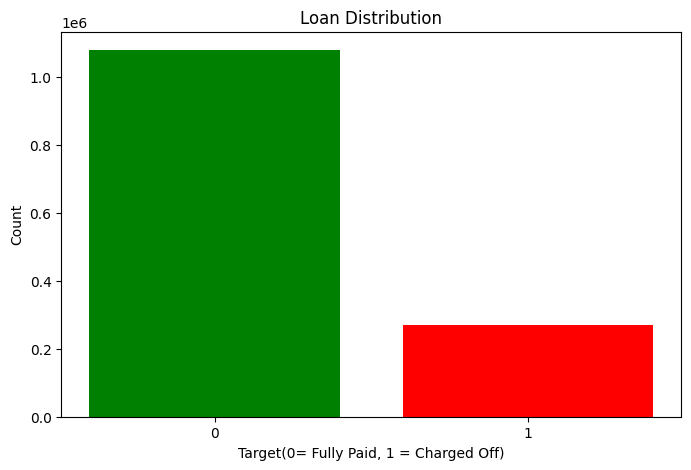

In [22]:

counts = df['Target'].value_counts()
fig, ax =plt.subplots(figsize=(8,5))
ax.bar(counts.index,counts.values, color=['green','red'])

ax.set_xlabel('Target(0= Fully Paid, 1 = Charged Off)')
ax.set_ylabel('Count')
ax.set_title('Loan Distribution')
ax.set_xticks([0,1])

In [23]:
df.isnull().sum()

id                             0
member_id                1348059
loan_amnt                      0
funded_amnt                    0
funded_amnt_inv                0
                          ...   
settlement_date          1314773
settlement_amount        1314773
settlement_percentage    1314773
settlement_term          1314773
Target                         0
Length: 152, dtype: int64

In [24]:
df.isnull().mean().sort_values(ascending=False)*100

member_id                                     100.000000
next_pymnt_d                                   99.796077
orig_projected_additional_accrued_interest     99.721155
hardship_amount                                99.573164
hardship_last_payment_amount                   99.573164
                                                 ...    
total_rec_int                                   0.000000
hardship_flag                                   0.000000
disbursement_method                             0.000000
debt_settlement_flag                            0.000000
Target                                          0.000000
Length: 152, dtype: float64

In [25]:
(df.isnull().mean() >0.5).sum()

np.int64(58)

In [26]:
cols_to_drop=df.columns[df.isnull().mean()>0.5].to_list()

In [27]:
cols_to_drop

['member_id',
 'desc',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'next_pymnt_d',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_revol_delinq',
 'revol_bal_joint',
 'sec_app_fico_range_low',
 'sec_app_fico_range_high',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_open_act_il',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'deferral_term',
 'hardship_amount',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_

In [28]:
df.drop(columns=cols_to_drop, inplace=True)

In [29]:
df

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,...,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,Target
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,...,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,...,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,...,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,...,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0
5,68426831,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,300xx,GA,10.20,0.0,Oct-1987,...,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,NaN,5 years,OWN,130000.0,Not Verified,Oct-2016,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,Home improvement,775xx,TX,20.59,0.0,Jul-2004,...,3.0,9.0,3.0,5.0,21.0,10.0,15.0,9.0,17.0,0.0,0.0,0.0,0.0,100.0,33.3,0.0,0.0,275356.0,54349.0,13100.0,77756.0,N,Cash,N,0
2260690,88948836,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,Chief Operating Officer,9 years,MORTGAGE,180792.0,Not Verified,Oct-2016,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,900xx,CA,22.03,0.0,Mar-2002,...,4.0,5.0,7.0,9.0,17.0,8.0,10.0,5.0,16.0,0.0,0.0,0.0,2.0,100.0,42.9,0.0,0.0,719056.0,148305.0,56500.0,95702.0,N,Cash,N,0
2260691,89996426,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,Sales Manager,3 years,MORTGAGE,157000.0,Source Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,Home improvement,863xx,AZ,10.34,0.0,Jun-2011,...,5.0,8.0,7.0,7.0,4.0,11.0,11.0,8.0,14.0,0.0,0.0,0.0,2.0,100.0,0.0,0.0,0.0,524379.0,122872.0,15800.0,23879.0,N,Cash,N,1
2260692,90006534,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,Manager,10+ years,RENT,150000.0,Not Verified,Oct-2016,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti.

In [30]:
df

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,...,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,Target
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,...,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,...,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,...,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,...,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0
5,68426831,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,300xx,GA,10.20,0.0,Oct-1987,...,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,NaN,5 years,OWN,130000.0,Not Verified,Oct-2016,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,Home improvement,775xx,TX,20.59,0.0,Jul-2004,...,3.0,9.0,3.0,5.0,21.0,10.0,15.0,9.0,17.0,0.0,0.0,0.0,0.0,100.0,33.3,0.0,0.0,275356.0,54349.0,13100.0,77756.0,N,Cash,N,0
2260690,88948836,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,Chief Operating Officer,9 years,MORTGAGE,180792.0,Not Verified,Oct-2016,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,900xx,CA,22.03,0.0,Mar-2002,...,4.0,5.0,7.0,9.0,17.0,8.0,10.0,5.0,16.0,0.0,0.0,0.0,2.0,100.0,42.9,0.0,0.0,719056.0,148305.0,56500.0,95702.0,N,Cash,N,0
2260691,89996426,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,Sales Manager,3 years,MORTGAGE,157000.0,Source Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,Home improvement,863xx,AZ,10.34,0.0,Jun-2011,...,5.0,8.0,7.0,7.0,4.0,11.0,11.0,8.0,14.0,0.0,0.0,0.0,2.0,100.0,0.0,0.0,0.0,524379.0,122872.0,15800.0,23879.0,N,Cash,N,1
2260692,90006534,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,Manager,10+ years,RENT,150000.0,Not Verified,Oct-2016,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti.

In [31]:
keep_cols=["loan_amnt","funded_amnt","funded_amnt_inv","term","int_rate","installment","grade","sub_grade","emp_length","home_ownership","annual_inc","verification_status",'purpose',"addr_state","dti","delinq_2yrs","earliest_cr_line","fico_range_low","fico_range_high","inq_last_6mths","open_acc","total_acc","pub_rec","revol_bal","revol_util","initial_list_status","application_type","Target"]
df=df[keep_cols]

In [32]:
df

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,total_acc,pub_rec,revol_bal,revol_util,initial_list_status,application_type,Target
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,13.0,0.0,2765.0,29.7,w,Individual,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,38.0,0.0,21470.0,19.2,w,Individual,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,6.0,18.0,0.0,7869.0,56.2,w,Joint App,0
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,35.0,0.0,21929.0,64.5,w,Individual,0
5,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,5.0,6.0,0.0,8822.0,68.4,w,Individual,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,5 years,OWN,130000.0,Not Verified,home_improvement,TX,20.59,0.0,Jul-2004,735.0,739.0,1.0,17.0,39.0,0.0,23833.0,34.0,f,Individual,0
2260690,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,9 years,MORTGAGE,180792.0,Not Verified,debt_consolidation,CA,22.03,0.0,Mar-2002,705.0,709.0,1.0,16.0,32.0,0.0,77480.0,85.2,f,Individual,0
2260691,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,3 years,MORTGAGE,157000.0,Source Verified,home_improvement,AZ,10.34,0.0,Jun-2011,735.0,739.0,0.0,14.0,18.0,0.0,111598.0,27.4,f,Individual,1
2260692,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,10+ years,RENT,150000.0,Not Verified,medical,NC,12.25,0.0,Aug-1997,665.0,669.0,0.0,12.0,28.0,4.0,7700.0,55.0,f,Individual,0


In [33]:
df.isnull().sum().sort_values(ascending=False)

emp_length             78545
revol_util               897
dti                      374
inq_last_6mths            30
delinq_2yrs               29
open_acc                  29
pub_rec                   29
total_acc                 29
earliest_cr_line          29
annual_inc                 4
loan_amnt                  0
funded_amnt                0
verification_status        0
home_ownership             0
grade                      0
sub_grade                  0
installment                0
int_rate                   0
funded_amnt_inv            0
term                       0
fico_range_high            0
fico_range_low             0
addr_state                 0
purpose                    0
revol_bal                  0
initial_list_status        0
application_type           0
Target                     0
dtype: int64

In [34]:
df['emp_length'].value_counts()

emp_length
10+ years    442669
2 years      122092
< 1 year     108533
3 years      107863
1 year        88842
5 years       84326
4 years       80761
6 years       62877
8 years       60808
7 years       59724
9 years       51019
Name: count, dtype: int64

In [35]:
df['emp_length']=df['emp_length'].fillna('Unknown')

In [36]:
df['emp_length'].value_counts()

emp_length
10+ years    442669
2 years      122092
< 1 year     108533
3 years      107863
1 year        88842
5 years       84326
4 years       80761
Unknown       78545
6 years       62877
8 years       60808
7 years       59724
9 years       51019
Name: count, dtype: int64

In [37]:
df=df.dropna()

In [38]:
df.shape

(1346788, 28)

In [39]:
df.isnull().sum().sum()

np.int64(0)

In [40]:
df.dtypes

loan_amnt              float64
funded_amnt            float64
funded_amnt_inv        float64
term                       str
int_rate               float64
installment            float64
grade                      str
sub_grade                  str
emp_length                 str
home_ownership             str
annual_inc             float64
verification_status        str
purpose                    str
addr_state                 str
dti                    float64
delinq_2yrs            float64
earliest_cr_line           str
fico_range_low         float64
fico_range_high        float64
inq_last_6mths         float64
open_acc               float64
total_acc              float64
pub_rec                float64
revol_bal              float64
revol_util             float64
initial_list_status        str
application_type           str
Target                   int64
dtype: object

In [41]:
df['term'].unique()

<StringArray>
[' 36 months', ' 60 months']
Length: 2, dtype: str

In [42]:
df['term_in_months']=df['term'].str.extract(r'(\d+)').astype(int)

In [43]:
df['term_in_months'].unique()

array([36, 60])

In [44]:
df=df.drop(columns="term")

In [45]:
df['emp_length'].unique()

<StringArray>
['10+ years',   '3 years',   '4 years',   '6 years',   '7 years',   '8 years',
   '2 years',   '5 years',   '9 years',  '< 1 year',    '1 year',   'Unknown']
Length: 12, dtype: str

In [46]:
emp_len_mapping={
    '< 1 year':0,
    '1 year' :1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'Unknown': -1
}

In [47]:
df['emp_length_num']=df['emp_length'].map(emp_len_mapping)

In [48]:
df=df.drop(columns=["emp_length"])

In [49]:
df['grade'].value_counts()

grade
B    392819
C    381909
A    235062
D    201371
E     94066
F     32259
G      9302
Name: count, dtype: int64

In [50]:
df['sub_grade'].unique()

<StringArray>
['C4', 'C1', 'B4', 'F1', 'C3', 'B2', 'B1', 'A2', 'B5', 'C2', 'E2', 'A4', 'E3',
 'C5', 'A1', 'D4', 'F3', 'D1', 'B3', 'D3', 'D5', 'A5', 'F2', 'E4', 'D2', 'E1',
 'F5', 'E5', 'A3', 'G2', 'G1', 'G3', 'G4', 'F4', 'G5']
Length: 35, dtype: str

In [51]:
sub_grades_order = ['A1','A2','A3','A4','A5',
                    'B1','B2','B3','B4','B5',
                    'C1','C2','C3','C4','C5',
                    'D1','D2','D3','D4','D5',
                    'E1','E2','E3','E4','E5',
                    'F1','F2','F3','F4','F5',
                    'G1','G2','G3','G4','G5']

In [52]:
sub_grade_mapping={grade: i+1 for i, grade in enumerate(sub_grades_order)}

In [53]:
sub_grade_mapping

{'A1': 1,
 'A2': 2,
 'A3': 3,
 'A4': 4,
 'A5': 5,
 'B1': 6,
 'B2': 7,
 'B3': 8,
 'B4': 9,
 'B5': 10,
 'C1': 11,
 'C2': 12,
 'C3': 13,
 'C4': 14,
 'C5': 15,
 'D1': 16,
 'D2': 17,
 'D3': 18,
 'D4': 19,
 'D5': 20,
 'E1': 21,
 'E2': 22,
 'E3': 23,
 'E4': 24,
 'E5': 25,
 'F1': 26,
 'F2': 27,
 'F3': 28,
 'F4': 29,
 'F5': 30,
 'G1': 31,
 'G2': 32,
 'G3': 33,
 'G4': 34,
 'G5': 35}

In [54]:
df['subgrade_num']=df['sub_grade'].map(sub_grade_mapping)

In [55]:
df=df.drop(columns=["grade","sub_grade"])

In [56]:
df

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,total_acc,pub_rec,revol_bal,revol_util,initial_list_status,application_type,Target,term_in_months,emp_length_num,subgrade_num
0,3600.0,3600.0,3600.0,13.99,123.03,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,13.0,0.0,2765.0,29.7,w,Individual,0,36,10,14
1,24700.0,24700.0,24700.0,11.99,820.28,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,38.0,0.0,21470.0,19.2,w,Individual,0,36,10,11
2,20000.0,20000.0,20000.0,10.78,432.66,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,6.0,18.0,0.0,7869.0,56.2,w,Joint App,0,60,10,9
4,10400.0,10400.0,10400.0,22.45,289.91,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,35.0,0.0,21929.0,64.5,w,Individual,0,60,3,26
5,11950.0,11950.0,11950.0,13.44,405.18,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,5.0,6.0,0.0,8822.0,68.4,w,Individual,0,36,4,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,18000.0,18000.0,18000.0,9.49,377.95,OWN,130000.0,Not Verified,home_improvement,TX,20.59,0.0,Jul-2004,735.0,739.0,1.0,17.0,39.0,0.0,23833.0,34.0,f,Individual,0,60,5,7
2260690,29400.0,29400.0,29400.0,13.99,683.94,MORTGAGE,180792.0,Not Verified,debt_consolidation,CA,22.03,0.0,Mar-2002,705.0,709.0,1.0,16.0,32.0,0.0,77480.0,85.2,f,Individual,0,60,9,13
2260691,32000.0,32000.0,32000.0,14.49,752.74,MORTGAGE,157000.0,Source Verified,home_improvement,AZ,10.34,0.0,Jun-2011,735.0,739.0,0.0,14.0,18.0,0.0,111598.0,27.4,f,Individual,1,60,3,14
2260692,16000.0,16000.0,16000.0,12.79,362.34,RENT,150000.0,Not Verified,medical,NC,12.25,0.0,Aug-1997,665.0,669.0,0.0,12.0,28.0,4.0,7700.0,55.0,f,Individual,0,60,10,11


In [57]:
df['earliest_cr_line'].head(10)

0     Aug-2003
1     Dec-1999
2     Aug-2000
4     Jun-1998
5     Oct-1987
6     Jun-1990
7     Feb-1999
8     Apr-2002
9     Nov-1994
12    Jun-1996
Name: earliest_cr_line, dtype: str

In [58]:
df['earliest_cr_line']=pd.to_datetime(df['earliest_cr_line'],format='%b-%Y')

In [59]:
reference_date=pd.to_datetime('2019-01-01')

In [60]:
df['credit_history_months']= ((reference_date-df['earliest_cr_line']).dt.days/30).astype(int)

In [61]:
df=df.drop(columns='earliest_cr_line')

In [62]:
df

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,total_acc,pub_rec,revol_bal,revol_util,initial_list_status,application_type,Target,term_in_months,emp_length_num,subgrade_num,credit_history_months
0,3600.0,3600.0,3600.0,13.99,123.03,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,675.0,679.0,1.0,7.0,13.0,0.0,2765.0,29.7,w,Individual,0,36,10,14,187
1,24700.0,24700.0,24700.0,11.99,820.28,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,715.0,719.0,4.0,22.0,38.0,0.0,21470.0,19.2,w,Individual,0,36,10,11,232
2,20000.0,20000.0,20000.0,10.78,432.66,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,695.0,699.0,0.0,6.0,18.0,0.0,7869.0,56.2,w,Joint App,0,60,10,9,224
4,10400.0,10400.0,10400.0,22.45,289.91,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,695.0,699.0,3.0,12.0,35.0,0.0,21929.0,64.5,w,Individual,0,60,3,26,250
5,11950.0,11950.0,11950.0,13.44,405.18,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,0.0,690.0,694.0,0.0,5.0,6.0,0.0,8822.0,68.4,w,Individual,0,36,4,13,380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,18000.0,18000.0,18000.0,9.49,377.95,OWN,130000.0,Not Verified,home_improvement,TX,20.59,0.0,735.0,739.0,1.0,17.0,39.0,0.0,23833.0,34.0,f,Individual,0,60,5,7,176
2260690,29400.0,29400.0,29400.0,13.99,683.94,MORTGAGE,180792.0,Not Verified,debt_consolidation,CA,22.03,0.0,705.0,709.0,1.0,16.0,32.0,0.0,77480.0,85.2,f,Individual,0,60,9,13,205
2260691,32000.0,32000.0,32000.0,14.49,752.74,MORTGAGE,157000.0,Source Verified,home_improvement,AZ,10.34,0.0,735.0,739.0,0.0,14.0,18.0,0.0,111598.0,27.4,f,Individual,1,60,3,14,92
2260692,16000.0,16000.0,16000.0,12.79,362.34,RENT,150000.0,Not Verified,medical,NC,12.25,0.0,665.0,669.0,0.0,12.0,28.0,4.0,7700.0,55.0,f,Individual,0,60,10,11,260


In [63]:
df['credit_history_months'].describe()

count    1.346788e+06
mean     2.410221e+02
std      9.263881e+01
min      3.900000e+01
25%      1.770000e+02
50%      2.240000e+02
75%      2.890000e+02
max      1.031000e+03
Name: credit_history_months, dtype: float64

In [64]:
df['initial_list_status'].value_counts()

initial_list_status
w    783232
f    563556
Name: count, dtype: int64

In [65]:
df['application_type'].value_counts()

application_type
Individual    1321406
Joint App       25382
Name: count, dtype: int64

In [66]:
df['initial_list_status']=df['initial_list_status'].map({"w":0,"f":1})
df['application_type']=df["application_type"].map({"Individual":0, "Joint App":1})

In [67]:
print(df['home_ownership'].value_counts())
print(df['verification_status'].value_counts())
print(df['purpose'].value_counts())
print(df['addr_state'].nunique())  # just count for states

home_ownership
MORTGAGE    666152
RENT        535260
OWN         144862
ANY            285
OTHER          180
NONE            49
Name: count, dtype: int64
verification_status
Source Verified    521225
Verified           418630
Not Verified       406933
Name: count, dtype: int64
purpose
debt_consolidation    780839
credit_card           295462
home_improvement       87570
other                  78095
major_purchase         29499
medical                15579
small_business         15563
car                    14627
moving                  9501
vacation                9064
house                   7286
wedding                 2348
renewable_energy         935
educational              420
Name: count, dtype: int64
51


In [68]:
df['home_ownership']=df['home_ownership'].replace(["ANY","OTHER","NONE"],"OTHER")

In [69]:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    666152
RENT        535260
OWN         144862
OTHER          514
Name: count, dtype: int64

In [70]:
df=df.drop(columns='addr_state')

In [71]:
df.dtypes[df.dtypes=='str']

home_ownership         str
verification_status    str
purpose                str
dtype: object

In [72]:
from sklearn.preprocessing import OneHotEncoder

cols=["home_ownership","verification_status","purpose"]

encoder=OneHotEncoder(drop='first',sparse_output=False)

encoded= encoder.fit_transform(df[cols])

encoded_cols=encoder.get_feature_names_out(cols)

encoded_df=pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

In [73]:
df=df.drop(columns=cols)
df=pd.concat([df,encoded_df], axis=1)

In [74]:
df.shape

(1346788, 41)

In [75]:
df.dtypes.value_counts()

float64    34
int64       7
Name: count, dtype: int64

In [76]:
df.columns.to_list()

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'open_acc',
 'total_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'initial_list_status',
 'application_type',
 'Target',
 'term_in_months',
 'emp_length_num',
 'subgrade_num',
 'credit_history_months',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'verification_status_Source Verified',
 'verification_status_Verified',
 'purpose_credit_card',
 'purpose_debt_consolidation',
 'purpose_educational',
 'purpose_home_improvement',
 'purpose_house',
 'purpose_major_purchase',
 'purpose_medical',
 'purpose_moving',
 'purpose_other',
 'purpose_renewable_energy',
 'purpose_small_business',
 'purpose_vacation',
 'purpose_wedding']

In [77]:
correlations=df.corr()["Target"].sort_values(ascending=False)
print(correlations)

Target                                 1.000000
subgrade_num                           0.266990
int_rate                               0.258604
term_in_months                         0.175798
dti                                    0.084251
home_ownership_RENT                    0.065980
inq_last_6mths                         0.065963
funded_amnt                            0.065342
loan_amnt                              0.065311
verification_status_Verified           0.065190
funded_amnt_inv                        0.064852
revol_util                             0.060008
installment                            0.051427
purpose_debt_consolidation             0.034507
open_acc                               0.027965
purpose_small_business                 0.026721
pub_rec                                0.026153
verification_status_Source Verified    0.019517
delinq_2yrs                            0.019256
application_type                       0.016226
purpose_moving                         0

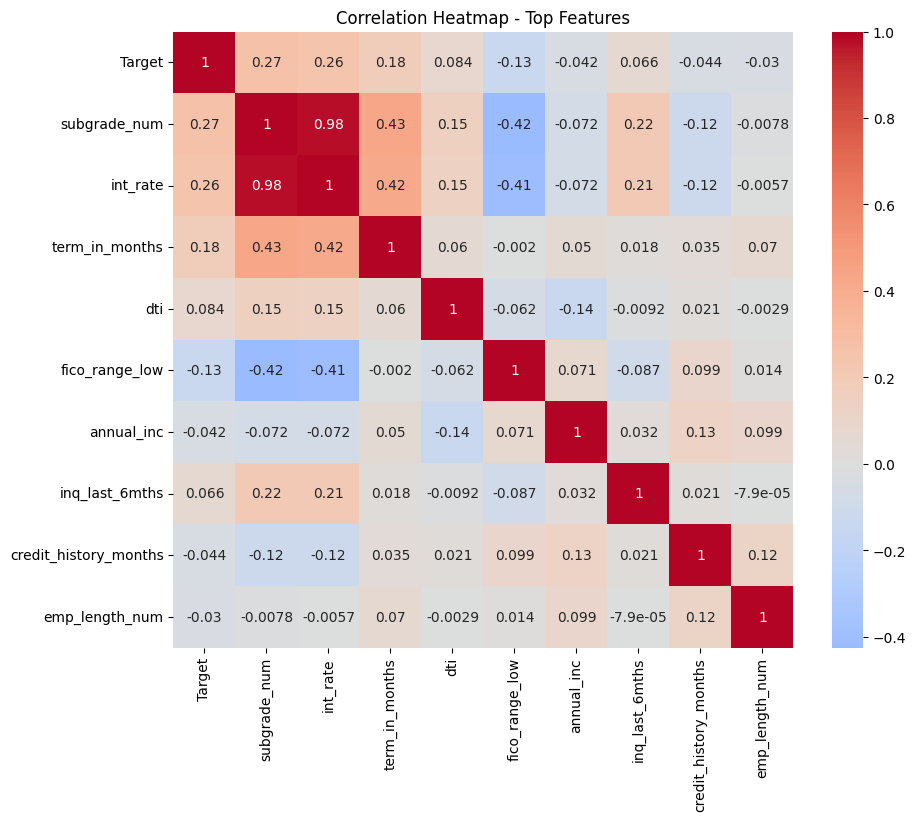

In [78]:
top_features=["Target","subgrade_num","int_rate",
              "term_in_months","dti","fico_range_low",
              "annual_inc","inq_last_6mths",
              "credit_history_months","emp_length_num"]

fig, ax= plt.subplots(figsize=(10,8))
sns.heatmap(df[top_features].corr(),annot=True,cmap='coolwarm', center=0,ax=ax)
ax.set_title("Correlation Heatmap - Top Features")
plt.show()

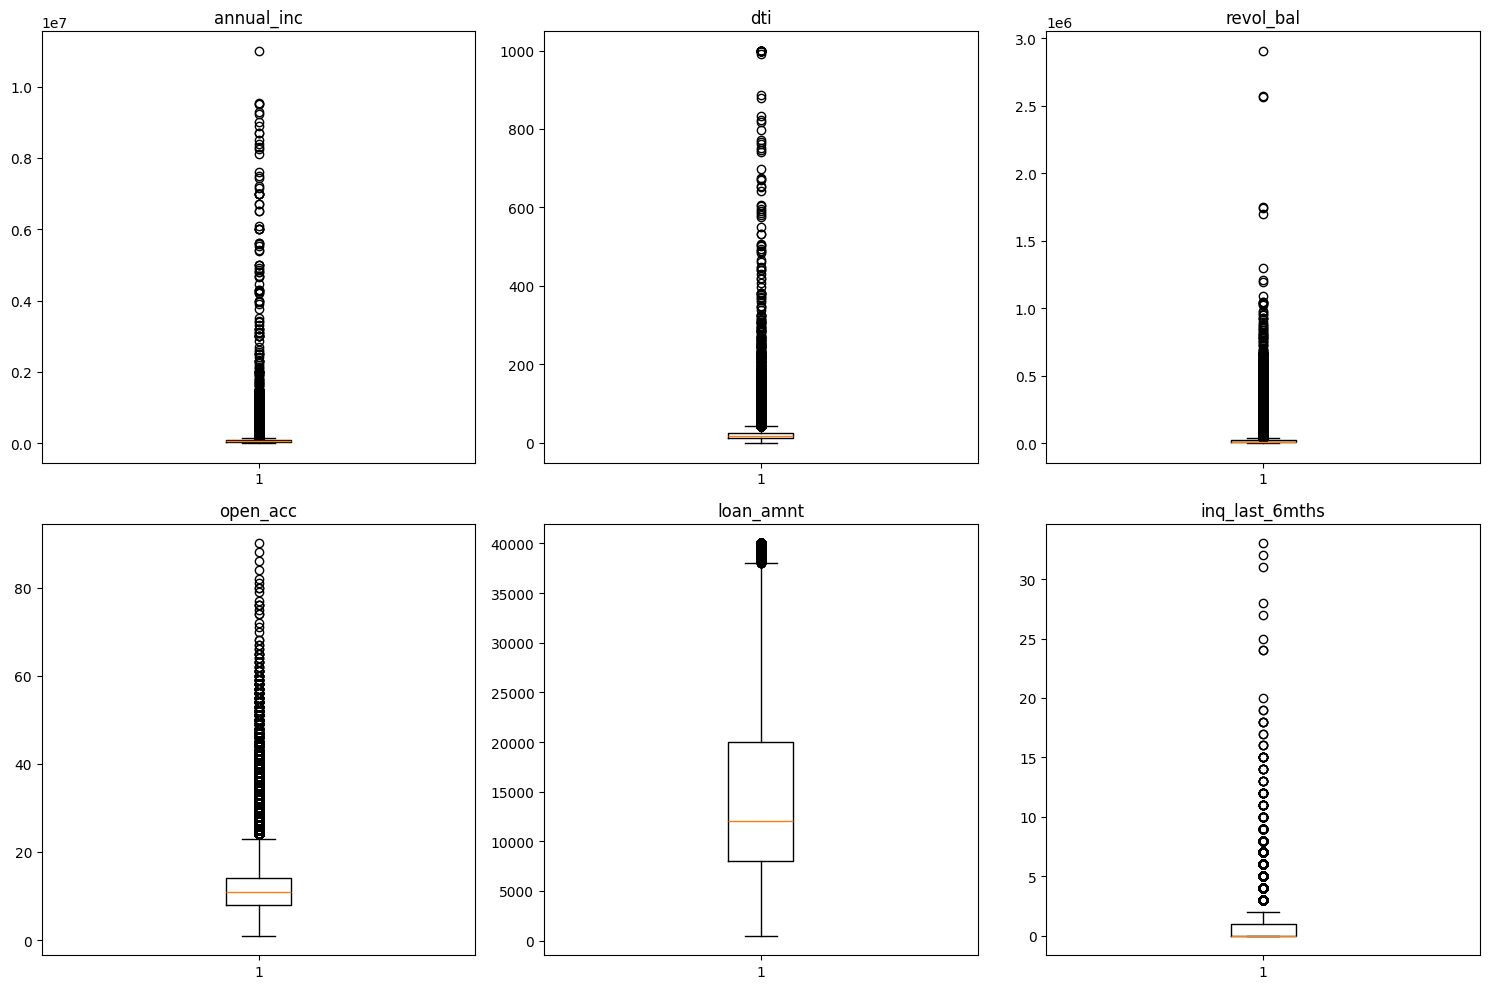

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols_to_check = ['annual_inc', 'dti', 'revol_bal', 'open_acc', 'loan_amnt', 'inq_last_6mths']

for i, col in enumerate(cols_to_check):
    ax = axes[i // 3, i % 3]
    ax.boxplot(df[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [80]:
print(df['annual_inc'].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))
print(df['dti'].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))
print(df['revol_bal'].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))


count    1.346788e+06
mean     7.624665e+04
std      6.985924e+04
min      1.600000e+01
1%       1.800000e+04
5%       2.800000e+04
95%      1.550000e+05
99%      2.500000e+05
max      1.099920e+07
Name: annual_inc, dtype: float64
count    1.346788e+06
mean     1.827683e+01
std      1.115632e+01
min     -1.000000e+00
1%       1.780000e+00
5%       4.970000e+00
95%      3.298000e+01
99%      3.847000e+01
max      9.990000e+02
Name: dti, dtype: float64
count    1.346788e+06
mean     1.627592e+04
std      2.246326e+04
min      0.000000e+00
1%       1.900000e+02
5%       1.679000e+03
95%      4.344465e+04
99%      9.532313e+04
max      2.904836e+06
Name: revol_bal, dtype: float64


In [81]:
# Cap annual_inc at 99th percentile
annual_inc_cap=df['annual_inc'].quantile(0.99)
df['annual_inc']=df['annual_inc'].clip(upper=annual_inc_cap)

In [82]:
# Cap revol_bal at 99th percentile
revol_bal_cap = df['revol_bal'].quantile(0.99)
df['revol_bal'] = df['revol_bal'].clip(upper=revol_bal_cap)

In [83]:
df[df['dti'] >50].shape

(2773, 41)

In [84]:
df=df[df['dti']<=50]
df.shape

(1344015, 41)

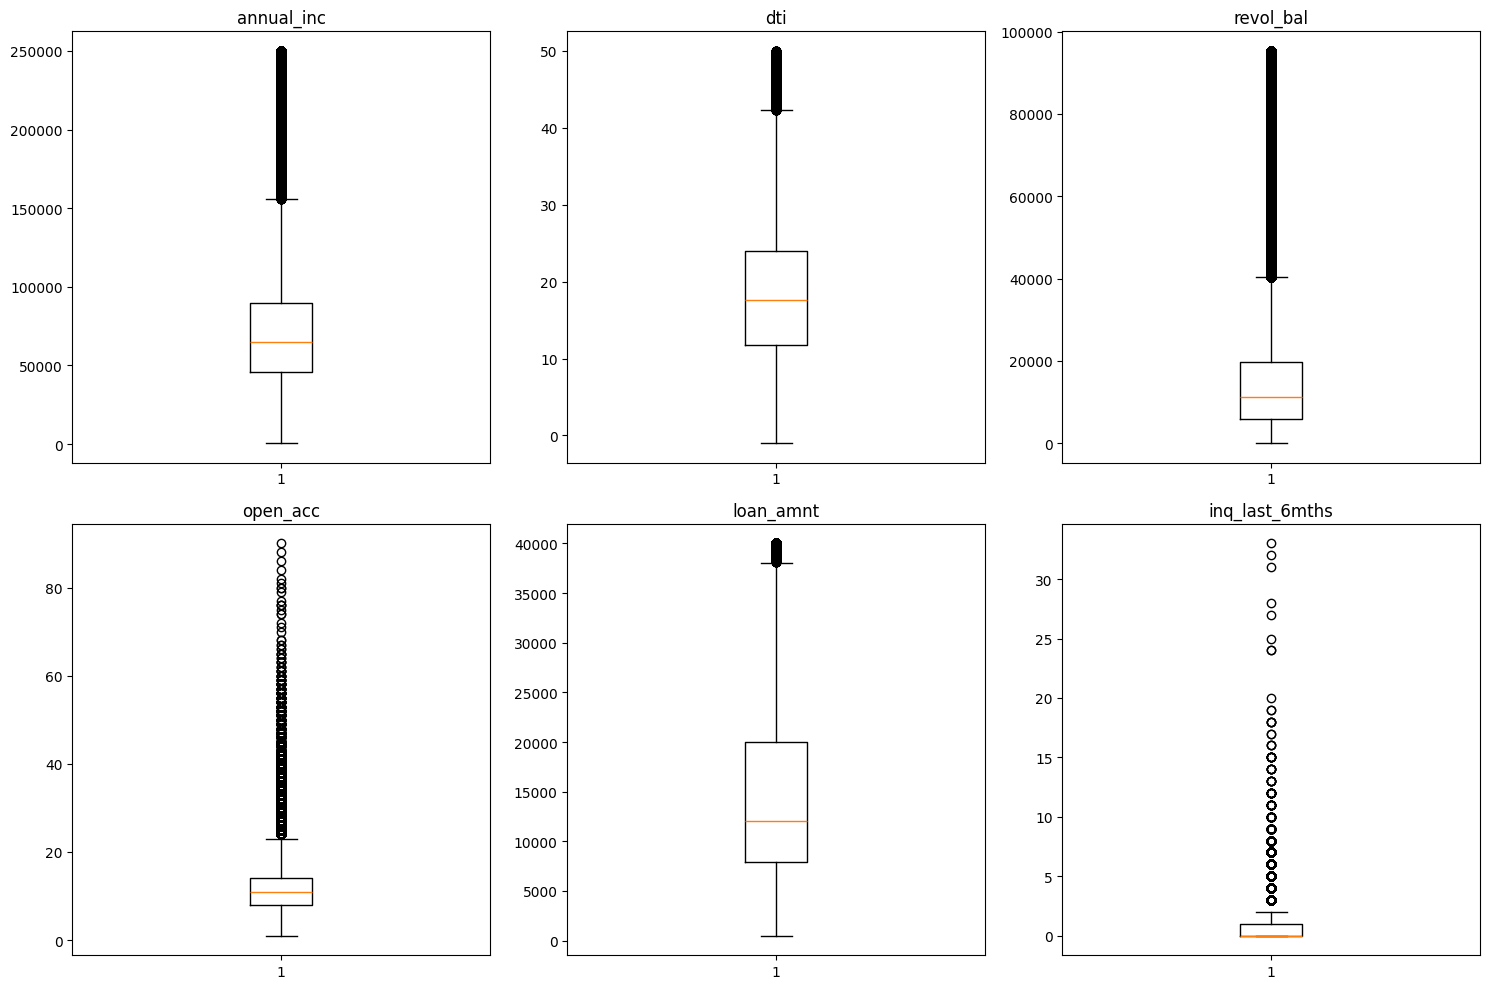

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols_to_check = ['annual_inc', 'dti', 'revol_bal', 'open_acc', 'loan_amnt', 'inq_last_6mths']

for i, col in enumerate(cols_to_check):
    ax = axes[i // 3, i % 3]
    ax.boxplot(df[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [86]:
df.to_csv('../data/cleaned_data/cleaned_data.csv', index=False)
print(f"Saved: {df.shape}")

Saved: (1344015, 41)


In [87]:
import pickle

# Save encoder
with open('../models/encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)


In [89]:
# Save cap values for later use
cap_values = {
    'annual_inc': annual_inc_cap,
    'revol_bal': revol_bal_cap,
    'dti_threshold':50  # for reference - rows above this were removed
}

with open('../models/cap_values.pkl', 'wb') as f:
    pickle.dump(cap_values, f)
